# Quantum ROM Demo

Presentation of the ideas as they were iterated upon for four quantum ROM implementations. 
None of the implementations are novel. Two of appear almost exactly in the paper https://doi.org/10.48550/arXiv.2204.03097, but even those are not incredibly different than the naive solution. 

In [15]:
from naive_solution import quantum_ROM
from naive_plus import quantum_ROM_1, quantum_ROM_2, quantum_ROM_3
from qiskit.quantum_info import Statevector

We need an interesting boolean function to see in the demo. 
I'll provide an arbitrary one so that the demo can be played with. 

Default values are set to $ (x, y, z) \mapsto (x, x \text{ XOR } z, x \text{ AND } (y \text{ OR } z))$

In [6]:
class CallableDict:
    def __init__(self, mapping : dict):
        self.mapping = mapping
    def __call__(self, key, default=None):
        return self.mapping.get(key, default)

n = 3
d = 3
    
f = CallableDict({
    (0, 0, 0): (0, 0, 0),
    (0, 0, 1): (0, 1, 0),
    (0, 1, 0): (0, 0, 0),
    (0, 1, 1): (0, 1, 0),
    (1, 0, 0): (1, 1, 0),
    (1, 0, 1): (1, 0, 1),
    (1, 1, 0): (1, 1, 1),
    (1, 1, 1): (1, 0, 1)
})

## The Naive Solution
The "Select" form of storage as presented in class. We use X gates to map a certain address to $|11111\rangle$. Then those qubits control X gates that flip the data qubits into the correct position. Repeat for each address. 

In the diagram, you will see barriers separating each "address block". 

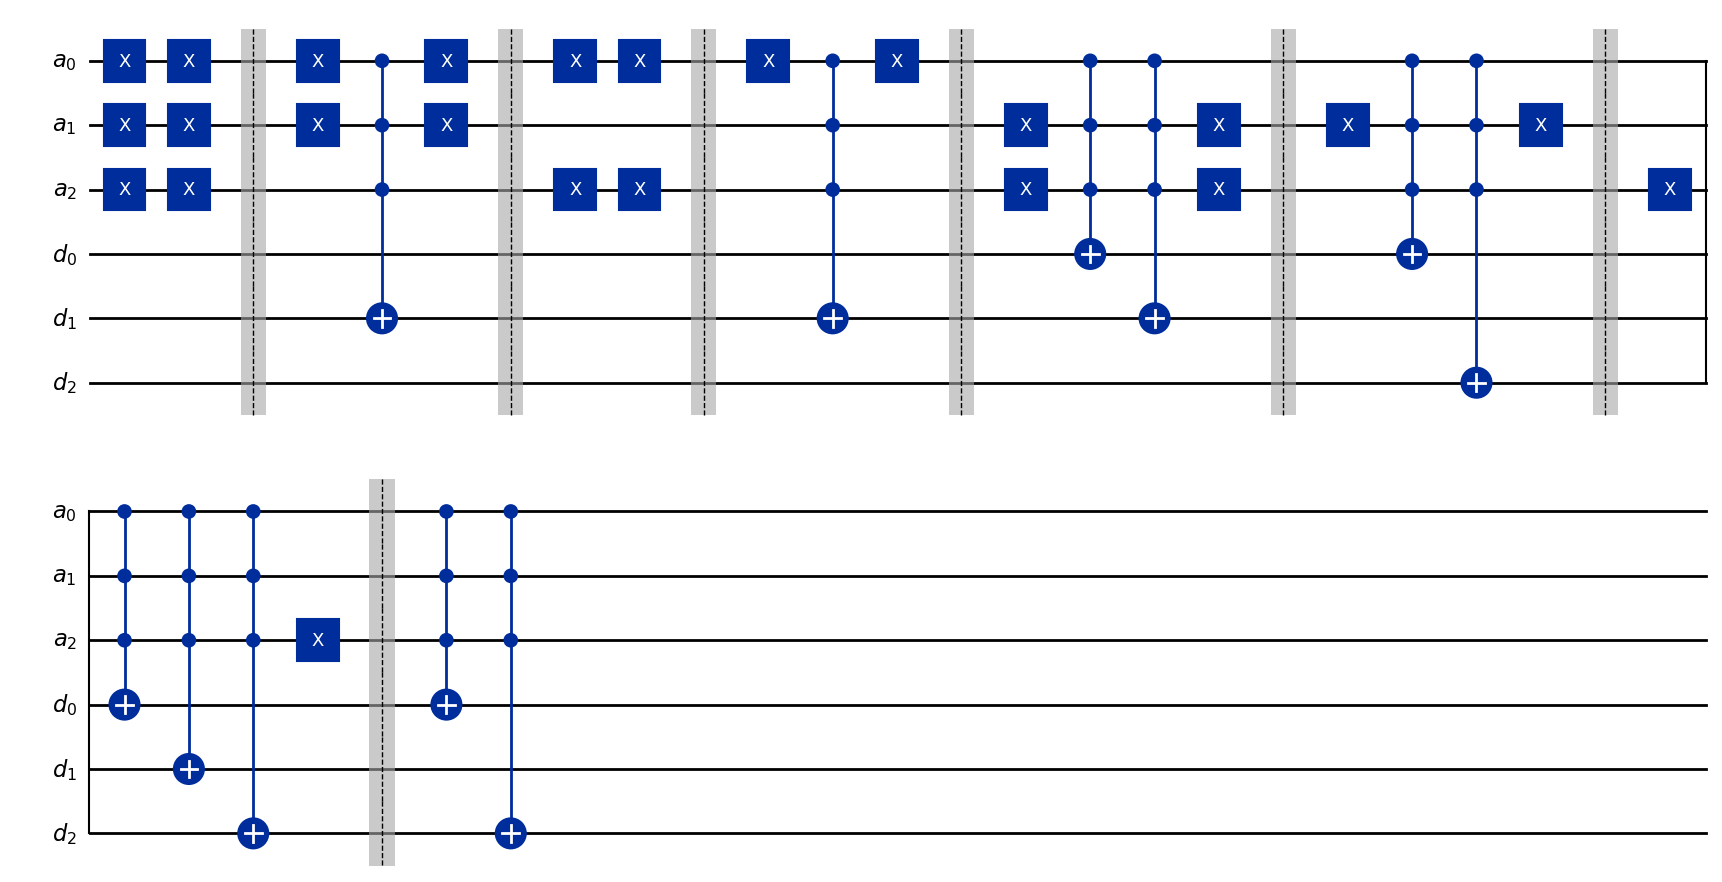

In [ ]:
circ0 = quantum_ROM(n, d, f, 
                    address_name='a', data_name='d', barriers=True)
circ0.draw(output='mpl')

Check that the data at $(1, 0, 0)$ is $(1, 1, 0)$. Recall this will be reversed by qiskit

In [24]:
state0 = Statevector.from_label("001")
state0 = Statevector.from_label("000").tensor(state0) # start with zeros in the data
state0.evolve(circ0).draw(output='latex')

<IPython.core.display.Latex object>

## Optimization 1
The first gate overuse to note is that every time we flip a bit in the data register, we need a multi-controlled X gate ($C^{n}X$). In the worst case, this could mean $d2^n$ $C^nX$ gates. We probably want to limit that if we can; those sound hard to make. 

Here's how we can limit it. With the addition of an ancillary qubit $c$, we can use one $C^nX$ gate to set $c$ to $|1\rangle$ when the right address is found and leave it zero if not. Then it only takes one more $C^nX$ to clear $c$ before the next address block, regardless of how large $d$ is. 

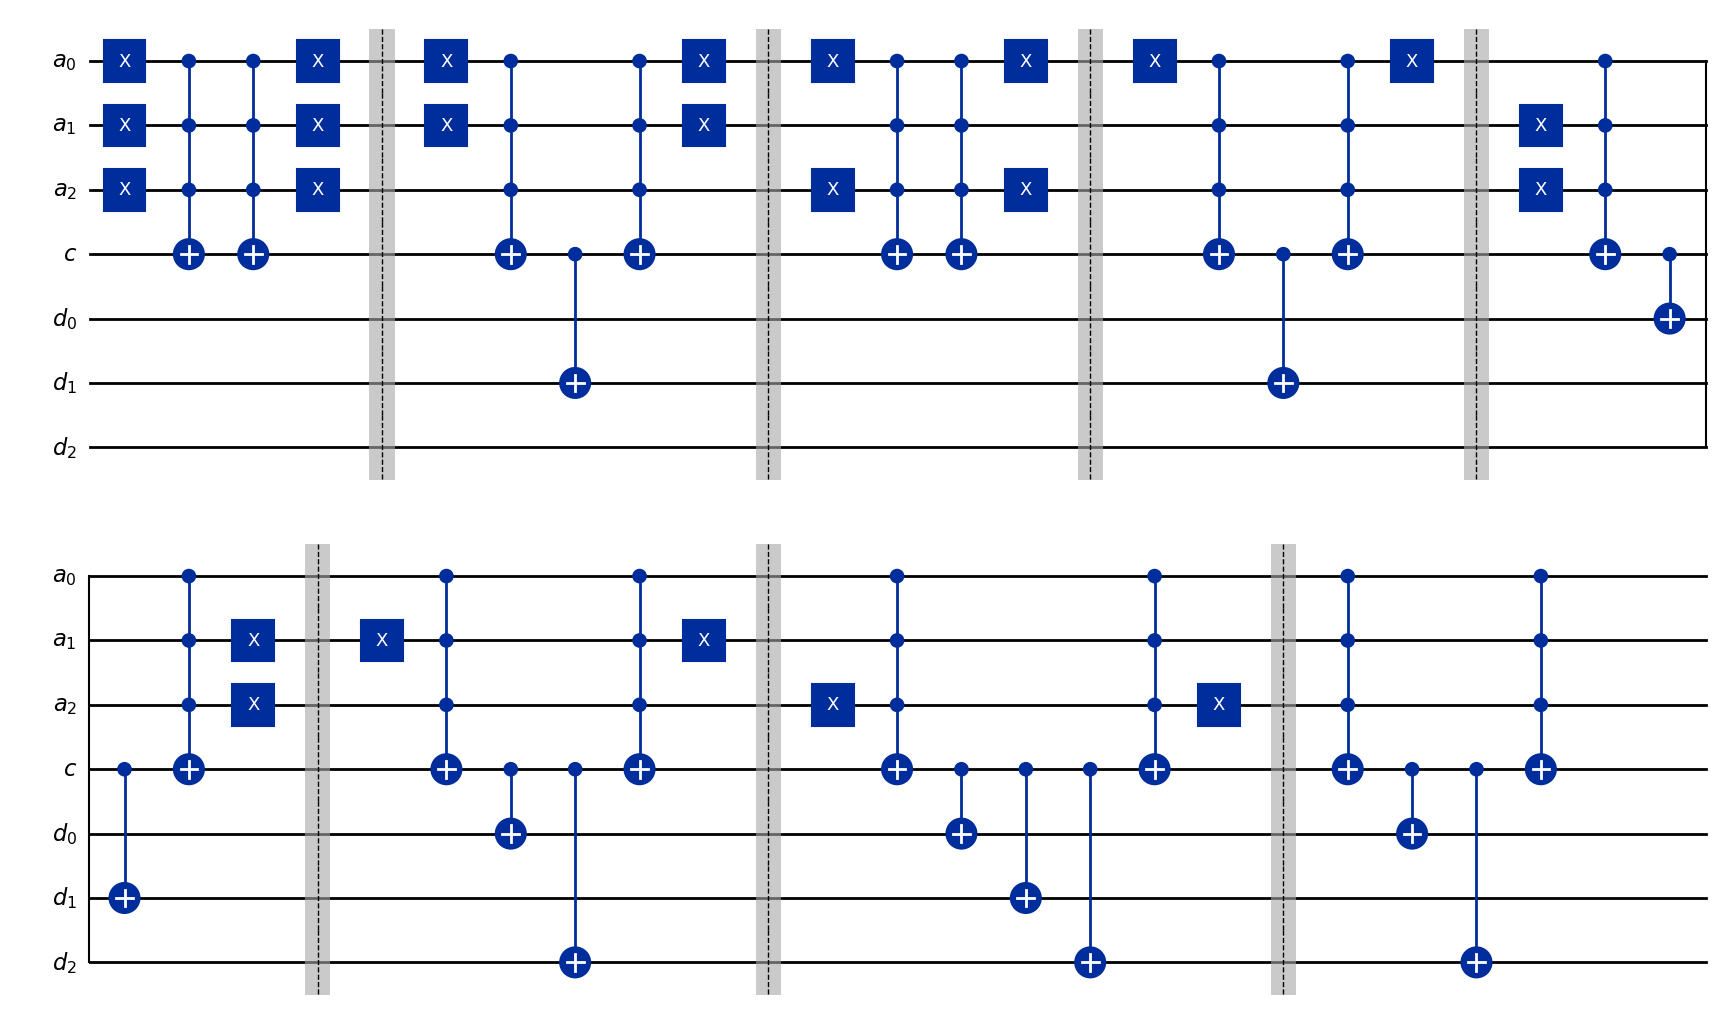

In [10]:
circ1 = quantum_ROM_1(n, d, f, address_name='a', data_name='d', control_name='c', barriers=True)
circ1.draw(output='mpl')

Note that we are still using two $C^nX$ gates even when there is no data to input (or it is all zeroes). This is an easy fix, and we implement it in both of the next two circuits. 

Check that the data at $(1, 0, 0)$ is $(1, 1, 0)$. Recall this will be reversed by qiskit

In [27]:
state1 = Statevector.from_label("001")
state1 = Statevector.from_label("0000").tensor(state1) # start with zeros in the data
state1.evolve(circ1).draw(output='latex')

<IPython.core.display.Latex object>

## Optimization 2
In each addresss block, we use one $C^nX$ gate to set the control line to 1 and one to set it back to 0. The next question is what if we never set it back to 0? 

We would need a control line for every address we hope to accesss now, $2^n$ in the worst case. We could set all of these lines up front instead of squeezing everything between computation and uncomputation. Call that process "pre-decoding". 

Then when we set data, we could either have our $CX$ gates controlled by a control line like before or directly from the "pre-decoded" per-address control lines. In this implementation, we chose to use an auxiliary control line for more consistent formatting. 

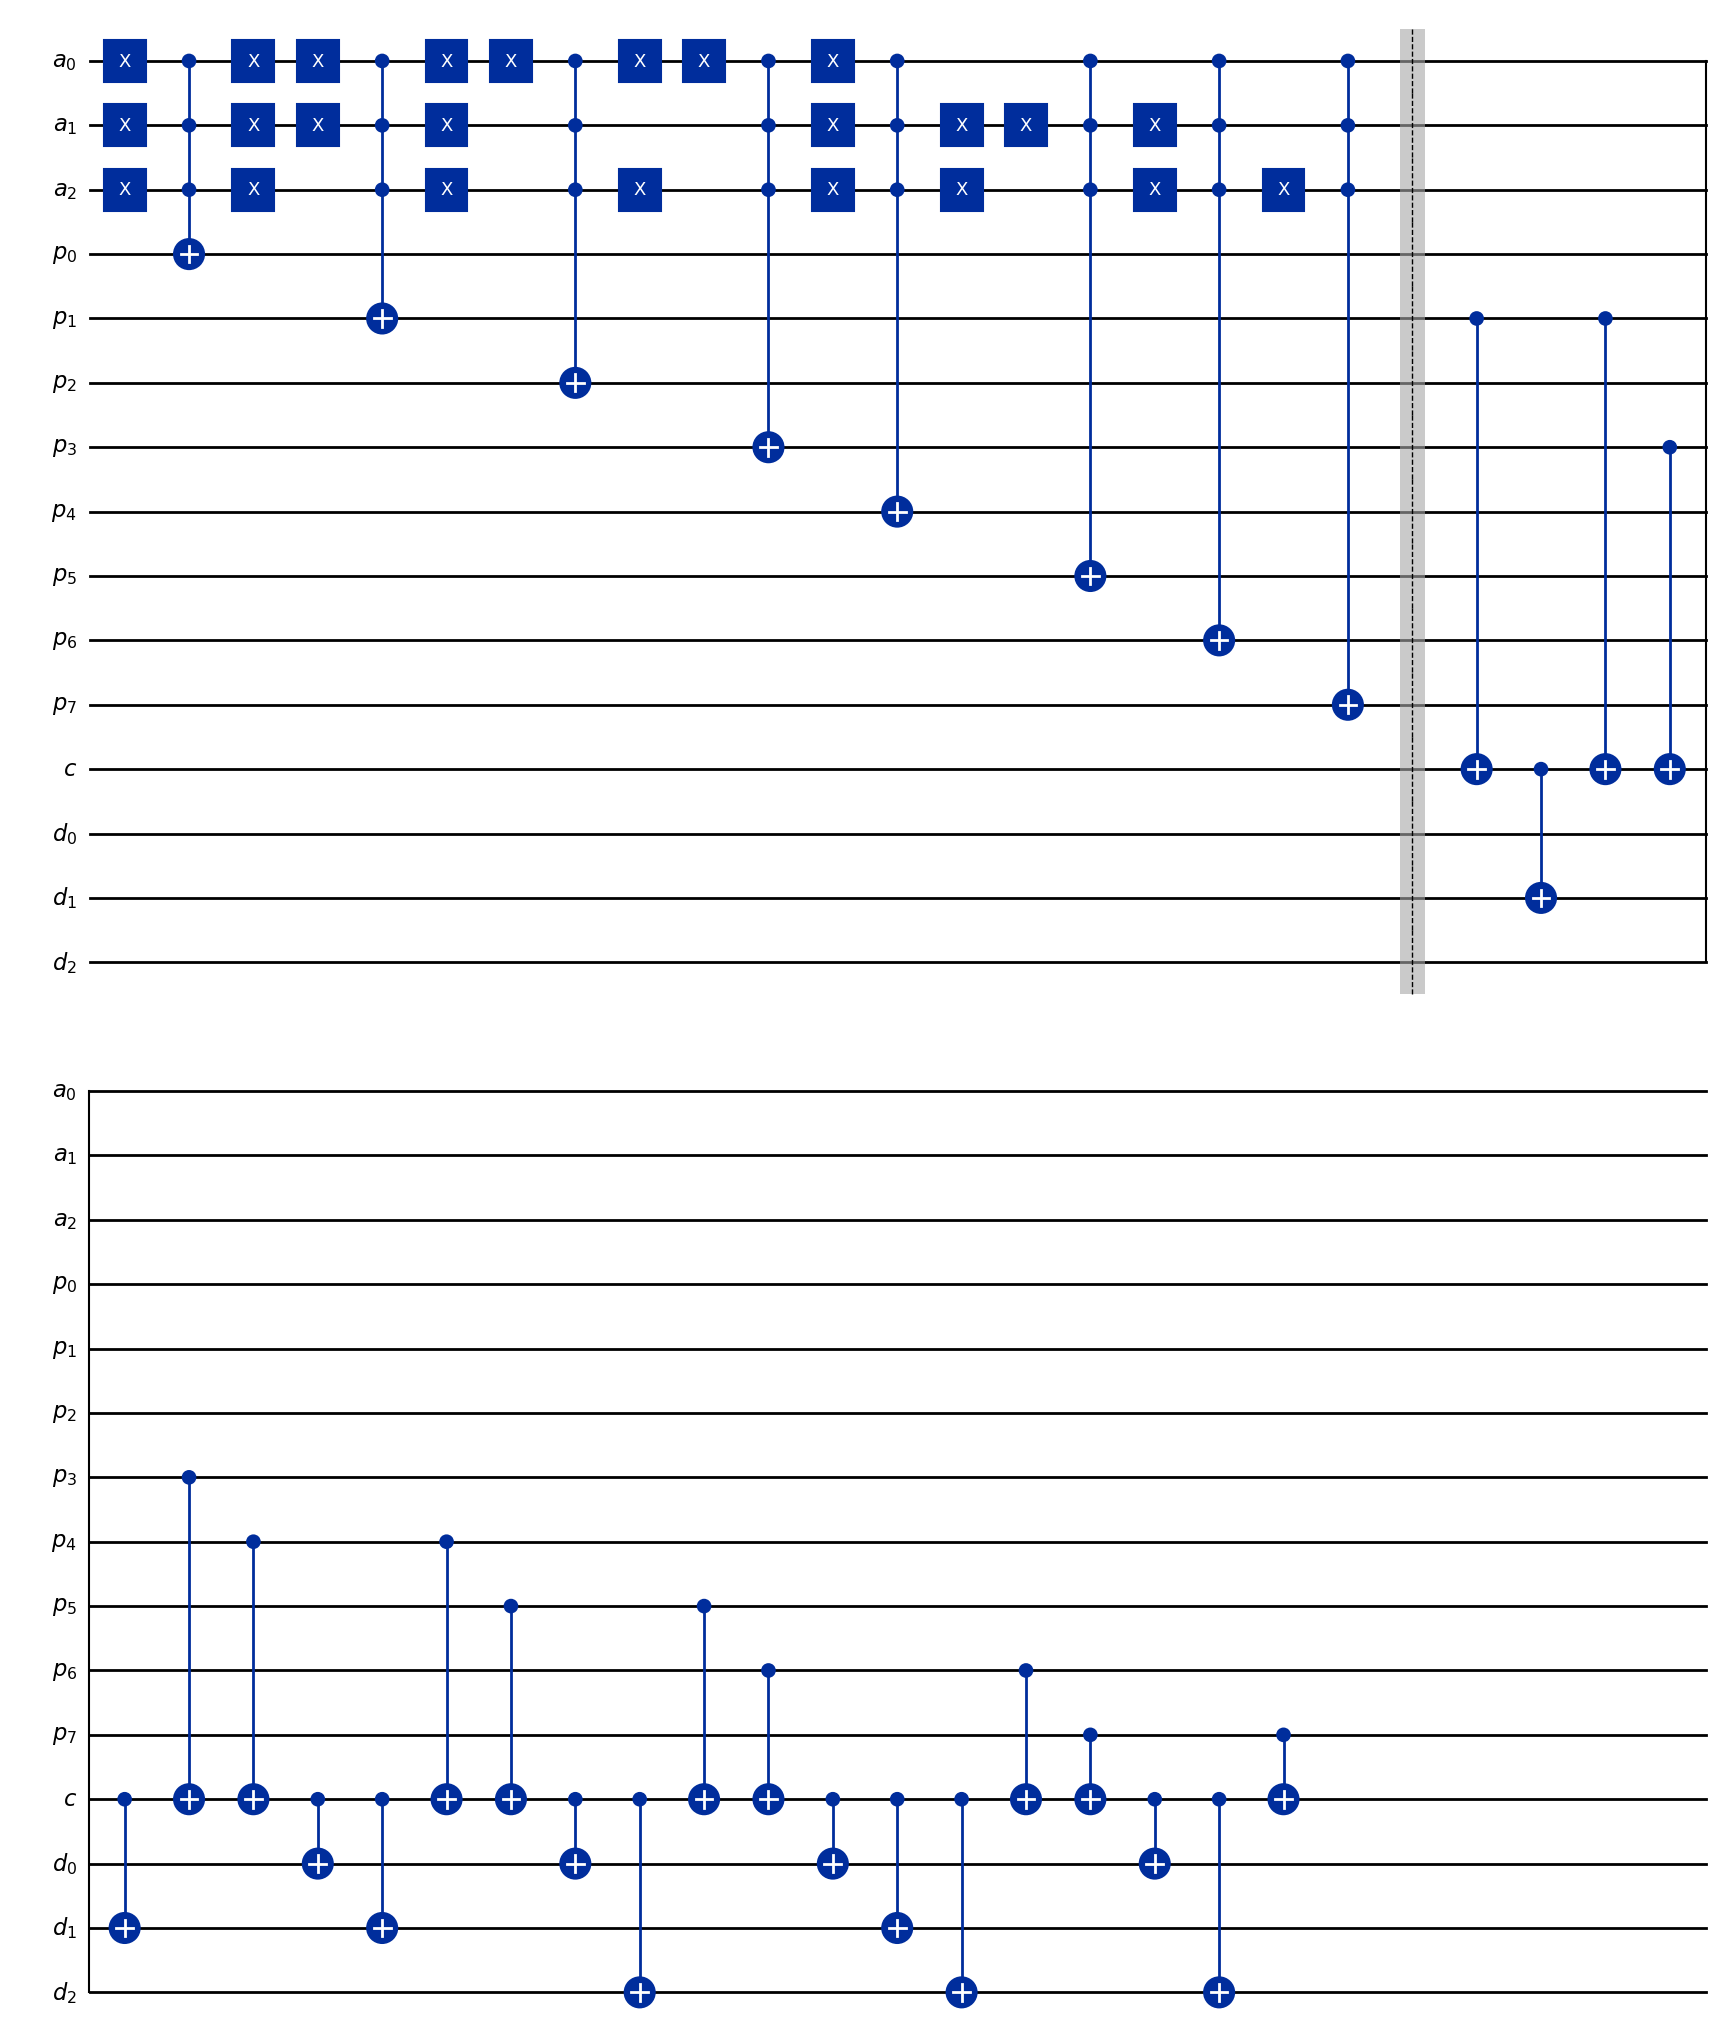

In [12]:
circ2 = quantum_ROM_2(n, d, f, address_name='a', data_name='d', control_name='c', predecoding_name='p', barriers=True)
circ2.draw(output='mpl')

Check that the data at $(1, 0, 0)$ is $(1, 1, 0)$. Recall this will be reversed by qiskit

In [29]:
state2 = Statevector.from_label("001")
state2 = Statevector.from_label("000000000000").tensor(state2) # start with zeros in the data
state2.evolve(circ2).draw(output='latex')

<IPython.core.display.Latex object>

## Optimization 3
At this point it's clear, that all I can find are micro-optimizations that don't really change the game with quantum ROM but optimize for the inefficiencies we can all see. 

In this version, I just did all of those optimizations I could think of, namely reducing the number of X gates I use by making sure two don't appear next to each other. I do that by walking through a binary counter and only adding X gates where bits actually flip. 

A fun follow-up would be to choose a smarter path to walk. Given $n$ and a number of items to store equal to $L < 2^n$, how do we get to all the addresses with the fewest X gates? Since we start at the address $|111111\rangle$ and don't care where we end, this is the one-way traveling salesman problem. 

1, 7, 110
3, 1, 010
4, 3, 111
5, 4, 001
6, 5, 011
7, 6, 001


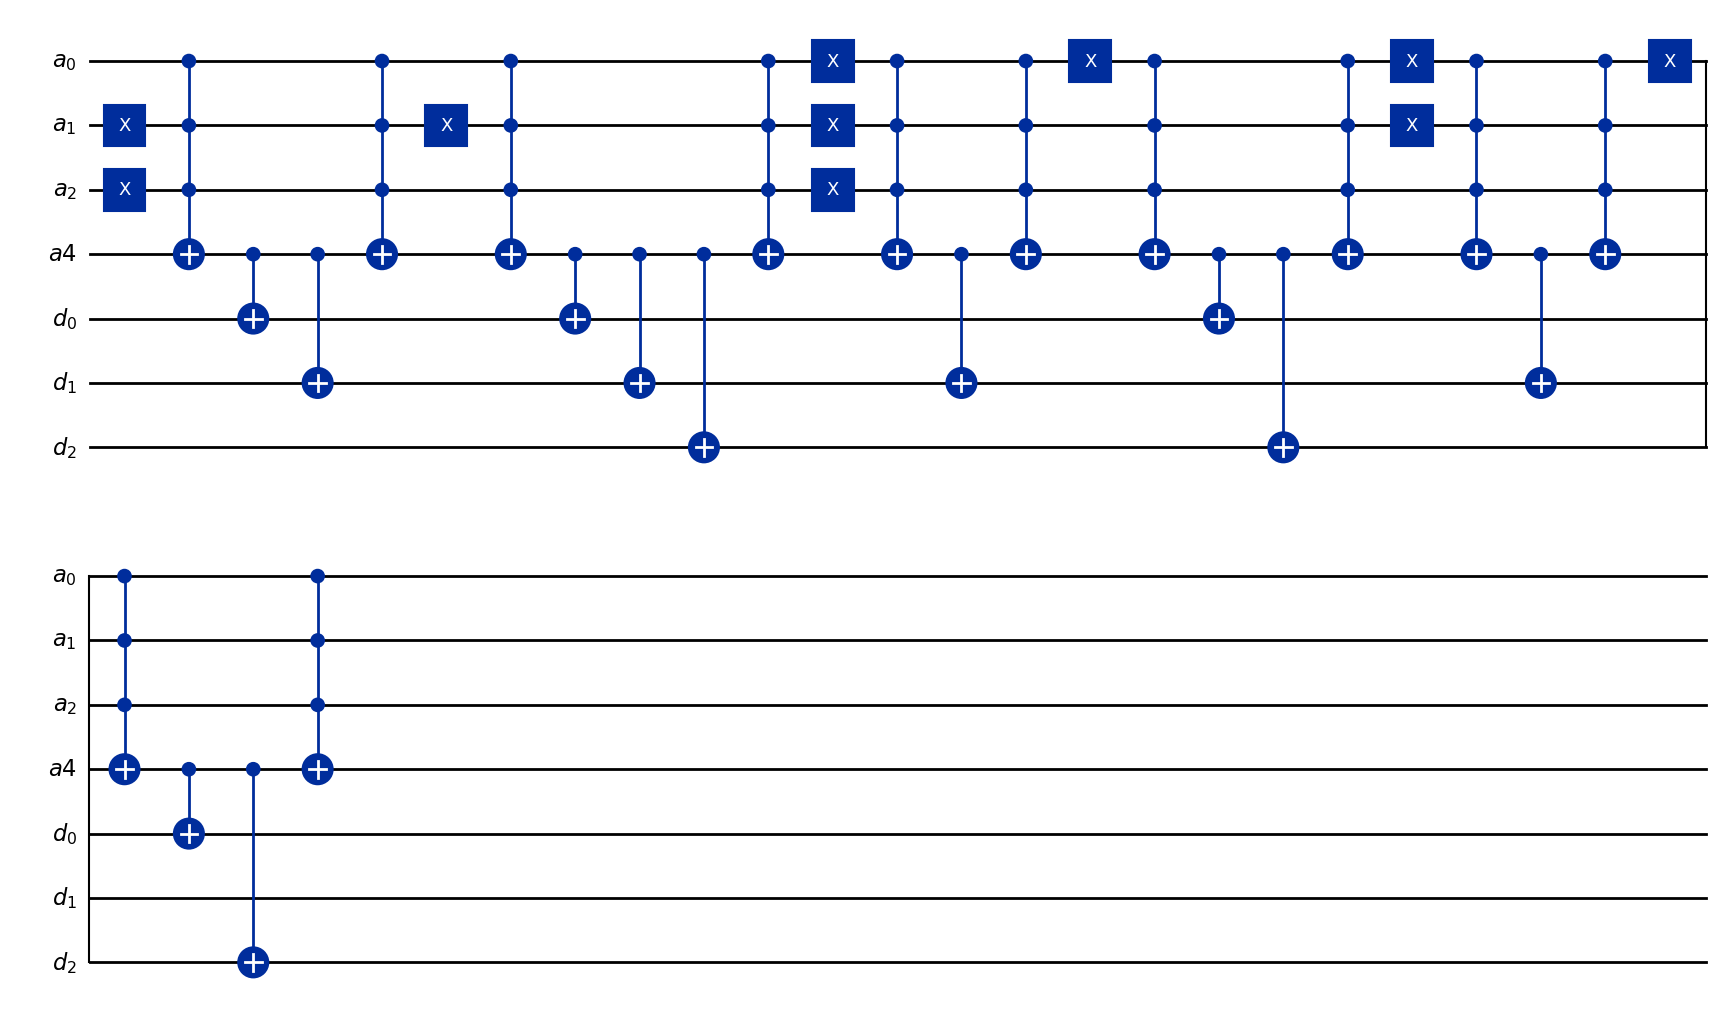

In [13]:
circ3 = quantum_ROM_3(n, d, f, address_name='a', data_name='d', barriers=True)
circ3.draw(output='mpl')

Check that the data at $(1, 0, 0)$ is $(1, 1, 0)$. Recall this will be reversed by qiskit

Note that we skip the $(0, 0, 0)$ address altogether because it takes no gates to set the data lines to $f(0, 0, 0) = (0, 0, 0)$

In [30]:
state3 = Statevector.from_label("001")
state3 = Statevector.from_label("0000").tensor(state3) # start with zeros in the data
state3.evolve(circ3).draw(output='latex')

<IPython.core.display.Latex object>